# Tutorial 7: Introduction to LangGraph

In this tutorial, we'll explore LangGraph, a powerful library for building complex, stateful workflows with language models.

## 1. What is LangGraph and how does it differ from LangChain?

LangGraph is an extension of LangChain that focuses on building stateful, multi-step workflows. While LangChain provides building blocks for working with language models, LangGraph allows you to create more complex, graph-based workflows with explicit state management.

Key differences:
- LangGraph introduces the concept of a 'graph' to represent workflows
- It provides better support for stateful applications
- LangGraph allows for more complex branching and conditional logic
- It's designed for building multi-agent systems and complex decision-making processes

## 2. Basic concepts: Nodes, Edges, and Graphs

In LangGraph:
- **Nodes** represent individual steps or actions in a workflow
- **Edges** define the connections and flow between nodes
- **Graphs** combine nodes and edges to create a complete workflow

These concepts allow you to create more structured and complex applications compared to linear chains in LangChain.

## 3. Setting up LangGraph

Let's start by importing the necessary modules and setting up our environment:

In [1]:
import os
from typing import Dict, TypedDict,List
from langchain_groq import ChatGroq
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.messages import BaseMessage
from langgraph.graph import StateGraph, END

# Set up the Groq LLM
llm = ChatGroq(
        model_name="llama-3.1-8b-instant",
        temperature=0.1,
        model_kwargs={"top_p": 0.5, "seed": 1337}
    )
# Define our state structure
class State(TypedDict):
    messages: List[BaseMessage]
    next_step: str

[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


## 4. Creating your first LangGraph flow

Let's create a simple conversational agent using LangGraph. This agent will greet the user, ask for their name, and then provide a personalized response.

In [2]:
# Define our graph
workflow = StateGraph(State)

# Define our nodes
def greet(state: State) -> State:
    state["messages"].append({"role": "assistant", "content": "Hello! What's your name?"})
    state["next_step"] = "get_name"
    return state

def get_name(state: State) -> State:
    name = state["messages"][-1]["content"]
    state["messages"].append({"role": "assistant", "content": f"Nice to meet you, {name}! How can I assist you today?"})
    state["next_step"] = "end"
    return state

# Add nodes to the graph
workflow.add_node("greet", greet)
workflow.add_node("get_name", get_name)

# Define edges
workflow.set_entry_point("greet")
workflow.add_edge("greet", "get_name")
workflow.add_edge("get_name", END)

# Compile the graph
app = workflow.compile()

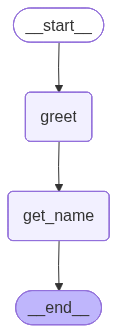

In [3]:
from IPython.display import Image, display

display(Image(app.get_graph().draw_mermaid_png()))

Now that we have created our simple LangGraph flow, let's test it:

In [4]:
# Initialize the state
initial_state = {"messages": [],"next_step":""}
# Run the graph
for event in app.stream(initial_state):
    for output in event.values():
        if "messages" in output:
            for message in output["messages"]:
                if message["role"] == "assistant":
                    print(f"Assistant: {message['content']}")
                elif message["role"] == "human":
                    print(f"Human: {message['content']}")
    
    # Check if 'next_step' exists
    if "next_step" in output and output["next_step"] == "get_name":
        user_input = "Alice"  # simulated user input
        output["messages"].append({"role": "human", "content": user_input})

print("Conversation ended.")

Assistant: Hello! What's your name?
Assistant: Hello! What's your name?
Human: Alice
Assistant: Nice to meet you, Alice! How can I assist you today?
Conversation ended.


## Conclusion

In this tutorial, we introduced LangGraph and created a simple conversational flow. We covered:
- **Nodes**: individual processing steps in a workflow
- **Edges**: connections that define the flow between nodes
- **StateGraph**: the main graph class with typed state

In the sections below we cover two fundamental LangGraph building blocks used throughout this tutorial series:
- **`MessagesState`**: a built-in state schema optimised for chat agents
- **`ToolNode`**: a prebuilt node that executes tool calls from an AI message

## 5. MessagesState and add_messages

`MessagesState` is a built-in shortcut for a chat state schema. Under the hood it is just a `TypedDict` with one key: `messages`, annotated with the `add_messages` reducer.

```python
# What MessagesState looks like internally:
from langgraph.graph.message import add_messages
from typing import Annotated, List

class ChatState(TypedDict):
    messages: Annotated[List, add_messages]
```

**Why `add_messages`?** Without a reducer, every state update would *overwrite* the message list. `add_messages` *appends* new messages and de-duplicates by message ID, which is exactly what a conversation history needs.

In [5]:
from langgraph.graph import MessagesState  # built-in convenience class
from langgraph.graph.message import add_messages
from langchain_core.messages import HumanMessage, AIMessage
from typing import Annotated, List
from typing_extensions import TypedDict

# MessagesState is equivalent to this custom TypedDict:
class ChatState(TypedDict):
    messages: Annotated[List, add_messages]  # add_messages reducer: appends, never overwrites

# Demonstrate add_messages behaviour
state: ChatState = {'messages': []}
state['messages'] = add_messages(state['messages'], [HumanMessage(content='Hello!')])
state['messages'] = add_messages(state['messages'], [AIMessage(content='Hi there!')])

print(f'Messages ({len(state["messages"])}):')
for msg in state['messages']:
    print(f'  {msg.__class__.__name__}: {msg.content}')

Messages (2):
  HumanMessage: Hello!
  AIMessage: Hi there!


## 6. ToolNode — Low-Level Tool Execution

`ToolNode` is a prebuilt LangGraph node that:
1. Reads the last `AIMessage` in `state['messages']`
2. Finds the `tool_calls` on it
3. Executes each tool and returns `ToolMessage` results

It works with any graph whose state has a `messages` key — including `MessagesState`. It also supports **parallel tool calls** if the model requests multiple tools in one turn.

In [6]:
from langgraph.prebuilt import ToolNode
from langchain_core.tools import tool
from langchain_core.messages import AIMessage

@tool
def get_weather(city: str) -> str:
    """Get the current weather for a city."""
    weather = {"Rome": "sunny, 22°C", "London": "cloudy, 14°C", "Tokyo": "rainy, 18°C"}
    return weather.get(city, f"Weather data unavailable for {city}")

@tool
def get_population(city: str) -> str:
    """Get the approximate population of a city."""
    pop = {"Rome": "2.8 million", "London": "9.6 million", "Tokyo": "14 million"}
    return pop.get(city, f"Population data unavailable for {city}")

tools = [get_weather, get_population]
tool_node = ToolNode(tools)

# ToolNode is designed to run inside a compiled graph.
# It reads the last AIMessage, executes its tool_calls, and returns ToolMessage results.
# You can also call tools directly without ToolNode:
direct_result = get_weather.invoke({"city": "Rome"})
print(f"Direct tool call: {direct_result}")

# Parallel tool calls: when a model returns multiple tool_calls in one AIMessage,
# ToolNode executes them all and returns one ToolMessage per call.
print("ToolNode defined. It will execute tool_calls inside the agent graph below.")

Direct tool call: sunny, 22°C
ToolNode defined. It will execute tool_calls inside the agent graph below.


## 7. Building a ReAct Agent with ToolNode + MessagesState

The classic ReAct loop is:
```
START → agent (LLM) → tools (ToolNode) → agent → ... → END
```

A conditional edge after the agent node decides whether to call tools or finish:
- If the last AI message has `tool_calls` → go to `tools`
- Otherwise → `END`

This is exactly what `create_react_agent` from `langgraph.prebuilt` does internally.

In [7]:
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from typing import Literal

# ChatState is already defined above (TypedDict with add_messages reducer)
agent_llm = ChatGroq(model_name='llama-3.1-8b-instant', temperature=0.1)
model_with_tools = agent_llm.bind_tools(tools)

def call_agent(state: ChatState):
    """LLM node: decide whether to call a tool or respond directly."""
    response = model_with_tools.invoke(state['messages'])
    return {'messages': [response]}

def should_use_tools(state: ChatState) -> Literal['tools', '__end__']:
    """Route to tools if the model made tool calls, otherwise end."""
    last = state['messages'][-1]
    return 'tools' if last.tool_calls else '__end__'

react = StateGraph(ChatState)
react.add_node('agent', call_agent)
react.add_node('tools', tool_node)
react.add_edge(START, 'agent')
react.add_conditional_edges('agent', should_use_tools, {'tools': 'tools', '__end__': END})
react.add_edge('tools', 'agent')  # loop back after tool execution
react_app = react.compile()

result = react_app.invoke({'messages': [HumanMessage(content='What is the weather in Rome and its population?')]})
print(result['messages'][-1].content)

Note: The actual weather and population may vary based on the current date and time. The provided information is a hypothetical example.


## Final Conclusion

In this tutorial we built up from the basics to a complete agent loop:
- `StateGraph` + `TypedDict` state → explicit, inspectable workflow
- `MessagesState` → the standard state schema for chat agents, with `add_messages` reducer built in
- `ToolNode` → prebuilt node that executes tool calls, including parallel calls, from any AIMessage
- **ReAct loop**: `agent → should_use_tools → tools → agent` — the foundation of all tool-using agents

In Tutorial 8 we explore more complex LangGraph flows including conditional routing, error handling, and multi-step workflows.